PROGETTO 8: IMAGE CAPTIONING

L'image captioning è un problema di ai in cui il sistema riceve un'immagine e genera automaticamente una descrizione testuale di ciò che vede.
La cosa importante è che non stiamo facendo semplice classificazione

La Computer Visione e la NLP smettono di essere vicini di casa e decidono di traslocare insieme
E' una sfida di traduzione ma non tra lingue, tra domini sensoriali.

Per affrontare questo compito abbiamo bisogno di una struttura che sappia sia vedere sia parlare.

- Architettura Encoder-Decoder: come collegare il mondo della computer Vision a quello del NLP, il ponte che unisce pixel e parole
- Processo di generazione testo: dall'estrazione delle feature visiva alla predizione sequenziale dei token. Come fa una macchina a scrivere una frase sensata una parola alla volta?
- Frontiere della multimodalità (sguardo al futuro): introduzione ai modelli CLIP e al concetto di embedding condiviso tra immagini e testo. Spazio dove immagini e testo parlano finalmente la stessa lingua.

Unione tra occhi e la voce dell'intelligenza artificiale

Architetura Encode-Decode per la Visione
L'Image Captioning rappresenta una delle sfide più affascinanti dell'intelligenza artificiale, richiedendo la capacità di comprendere non solo oggetti presenti in una foto, ma anche le loro relazioni semantiche.
Per risolvere questo task, adottiamo un approccio ibrido che sfrutta la potenza delle rete convoluzionali per la percezione e delle reti ricorrenti per la narrazione
La CNN funge da Encoder, comprimendo l'informazione visiva in un vettore di caratteristiche ad alta densità. 
Questo vettore diventa poi il seme, o lo spazio iniziale, per una LSTM che agisce da Decoder, generando una parola alla volta in una sequenza coerente.

La sinergia tra VNN e LSTM per interpretare e descrivere scene visiva
Immagina una gara a staffetta, l'encoder è il primo corridore, corre nel mondo delle immagini, cattura l'essenza della scena, e passa il testimone.
Il testimone è un vettore di numeri, una sintassi purissma della foto
Il secondo corridore è il decoder, che prende quel vettore di numeri e inzia a tradurne le parole
Non stiamo più solo classificando un oggetto, stiamo cercando di interpretare una relazione semantica tra tutto ciò che appare nel frame.

Ma quali sono gli strumenti che permettono questo passaggio di testimone?

Fusione di Visione e Linguaggio
Componenti strutturali del modello captioning
Per vedere usiamo una CNN, come una ResNet preaddestrata privata dell'ultimo layer di classificazione; è il nostro Encoder
Per parlare usiamo una LSTM, una rete neurale ricorrente che riceve il vettore visivo e produce una sequenza temporale di parole basata sulla probabilità condizionata; è il nostro Decoder
Un concetto fondamentale è il Teacher Forcing: tecnica di addestramento in cui la parola corretta al tempo t viene passata come input al tempo t+1 per stabilizzare l'apprendimento.
Immagina di insegnare ad un bambino a leggere, se sbaglia una parola diciamo subito quella corretta, per non far portare l'errore fino alla fine del testo. Anche in  una rete facciamo così, usiamo la parola reale precedente per guidare la predizione di quella successiva durante l'addestramento.

Come trasformiamo esattamente una griglia di pixel in un seme per il linguaggio?

Dall'Immagine al Vettore Latente
Il ramo Encoder (CNN) non ci serve che classifiche l'immagine come 'cane' o 'gatto', ci serve che ci dia la sua mappa di feature. Spesso utilizziamo il layer di Global Average Pooling per ottenere un vettore piatto che riassume l'intera scena visiva.
Il vettore così estratto dalla CNN viene solitamente proiettato in uno spazio che la LSTM può capire. E come se l'Encoder scrivesse un telegramma cifrato per descrivere la scena ed il Decoder fosse l'unico ad avere la chiave per decifrarlo e trasformarlo in prosa. tramite un layer denso, per corrispondere alla dimensione dello stato nascosto della LSTM, fornendo il 'contesto' iniziale per la generazione del testo.
La concatenazione avviene passando il vettore visivo come primo input delle sequenza o sommandolo allo stato interno della cella ricorrente, permettendo alla LSTM di 'vedere' l'immagine mentre scrive.

Naturalmente tutto questo deve essere guidato da un obbiettivo matematico preciso

La Funzione Loss per il Captioning
Ottimizzazione della sequenza testuale.
Come facciamo a dire al modello che la sua descrizione è giusta? usiamo la cross-entropy.
Vogliamo che il modello massimizzi la probabilità di generare la sequenza esatta di parole rispetto ad un essere umano che scrive guardando l'immagine.
E un lavoro di squadra, usiamo occhi e voce contemporaneamente.
Il modello viene addestrato minimizzando la cross-entropy sparsa tra la parola predettta dal decoder e la parola reale della descrizione fornita nel dataset di training.
L'obbiettivo è massimizzare la probabilità della sequenza corretta 'S' data l'immagine 'i', ottimizzando i parametri dell'encoder e del decoder simultaneamente.

Una volta addestrato il modello deve iniziare a camminare con le sue gambe.
Entriamo nella fase di generazione

Generazione della Descrizione
Meccanismi di inferenza e campionamento della sequenza.
Durante l'inferenza, il modello non ha accesso alla risposta corretta. Deve generare la descrizione parola per parola partendo da un token speciale di inzio sequenza, utilizzando la propria predizione precedente come input per il passo successivo.
Ogni parola scritta è un mattone per la parola successiva, un errore all'inizio si porta avanti fino alla fine.

Esploreremo come la strategia di campionamento influenzi la qualità del testo generato, passando dalla semplice scelta della parola più probabile a tecniche più sofisticate che garantiscono variabilità e naturalezza.

Esisteno diversi metodi per scegliere queste parole, ognuna con i suoi pro e contro

Tecniche di GEnerazione Testuale
Algoritmi per la selezione dei token
- Greedy Search: selezione sistematica della parole con la probabilità più alta in ogni istante temporale, veloce ma spesso ripetitiva.
- Beam Search: mantenimento di un set di 'k' ipotesi candidate per esplorare persorsi multipli e trovre la sequenza globalmente più probabile. E' come provare 3 o 4 trame diverse per un libro e scegliere alla fine solo quella migliore. E' più costosa ma produce descrizioni molto più umane e variegate.
- Tokenizzazione e Vocabolario: mappatura delle parole in indici numerici e gestione dei token speciale come 'startseq' e 'endseq'
- Word Embeddings: trasformazione degli indici in vettori densi che catturano le relazione semantiche tra le parole nel decoder.

Per far funzionare tutto questo dobbiamo gestire i dati in modo metocoloso

Dinamiche del Decoding
Il processo continua finchè il modello non produce il toekn di fine sequenza o finchè non viene raggiunta una lunghezza massima predefinita per la frase.
Durante l'addestramento, le descrizioni hanno lunghezze diverse. Utilizziamo il passing per uniformare le sequenze e maschere per evitare che il modello impari dal riempimento vuoto.
L'ultimo layer del decoder è un softmax applicato sull'intero vocabolario, restituendo una distribuzione di probabilità per ogni possibile parola successiva (rappresentazione One-Hot).

Fondamentale è il segnale di stop, il token di fine sequenza, senza questo la nostra ai continurebbe a parla all'infinito.

Possiamo però controllare quanto questa voce debba essere sicura o creativa.
Entra in gioco la temperatura della softmax

Softmax e Temperatura di Campionamento
Controllo della creatività del decoder
La funzione softmax normalizza i logit in probabilità. Itroducendo un parametro di temperatura, possiamo appiattire o accentuare questa distribuzione per favorire parole meno frequenti.
Una temperatura alta aumenta l'entropia della distribuzione, rendendo il modello più creativo ma potenzialmente meno coerente nella descrizione dell'immagine.

Esiste un modo per far parlare visione e testo senza usare una LSTM

Modelli multipli moderni: CLIP
Contrastive Language-Imagge Pre-training e il futuro di captionig
CLIP è come una persona che ha passato anni a guardare le foto in internet con le relative didascalie. Non cerca di generare testo da zero, cerca di capire se un'immagine e una frase, si appartengono. 
I modelli tradizionali Encoder-Decoder richiedono dataset annotati molto costosi. CLIP sviluppatto da OpenAI, ha rivoluzionato il campo imparanndo a collegare immagini e testi attraverso un ennorme dataset di coppie trovate sul web.
Invece di predire parole, CLIP impara uno spazio di embedding comune in cui un'immaginee e la sua descrizione testuale sono rapprreseente da vettori quasi identici. Vedremo come questo concetto faciliti la ricerca e la classificazione zero-shot.

Vediamo come CLIP riesce a mettere d'accordo questi due mondi cos' diversi.

L'Approccio Contrastivo
Connetter domini diversi in uno spazio condiviso
- Dual Encoder: utilizzo di un encoder per le immagini (es. ViT) e uno per il testo (es. Transformer) che lavorano in parallelo.
- Spazio Latente Comune: la proiezione di feature visive e testuali nello stesso numero di dimensioni per permettere il calcolo della similarità
- Contrastive Loss: funzione che spinge i vettori di coppie correlate ad avvicinarsi e allontana quelli di coppie casuali.
- Zero-shot: capacità di classificare immagini in categorie mai viste durante il training semplicemente fornendo una descrizione testuale.

Il potere di CLIP
Per confrontare un'immagine con una didascalia in CLIP calcoliamo il prodotto scalare tra i loro embedding normalizzati. Più il vlaore è vicino a 1, più la descrizione è accurata (similarità Coseno). 
Mentra le LSTM (modelli classici) sono vincolate a una vocabolario predefinito, CLIP (avendo conosciuto internet) può gestire concetti nuovi grazie alla natura aperta del suo encoder testuale basato su Transformer (superamento del vocabolario Fisso)
CLIP viene oggi utilizzato come motore per modeli generativi come DALL-E o per sistemi di ricerca semantica di immagini basati su linguaggio naturale.

Se sai associare correttamente la parola 'astronauta' puoi fare anche l'inverso, generare un'immagine partendo dal testo 'astronauta'

Ma come misuriamo questa vicinanza semantica in termini matematici?
Similarità di CLIP (similarità coseno)
Misurare la coerenza tra immagine e testo
L'efficacia di CLIP risiede nella normalizzazione dei vettori, trasformando la ricerca semantica in un problema di geometria lineare in alta dimensione.
La similarità tra l'embedding visivo 'v' e l'embeding testuale 't' è il fondamento per decidere se una didascalia descriver correttamente una scena.


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- 1. Caricamento Dataset Pokemon ---


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\barbara\.cache\huggingface\hub\datasets--svjack--pokemon-blip-captions-en-zh. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 833/833 [00:00<00:00, 2358.69 examples

Dataset caricato: 833 campioni trovati.

--- 2. Preprocessing dei Dati ---
Vocabolario costruito correttamente.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Inizio estrazione delle caratteristiche visive...
Forma dei vettori visivi estratti: (833, 1280)

--- 3. Creazione delle Sequenze di Training ---
Totale campioni generati per il training: 8568

--- 4. Costruzione e Addestramento del Modello ---
Epoch 1/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - loss: 3.7855
Epoch 2/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - loss: 2.3088
Epoch 3/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 179ms/step - loss: 1.7092
Epoch 4/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - loss: 1.4145
Epoch 5/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - loss: 1.1933
Epoch 6/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - loss: 1.0292
Epoch 7/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - loss: 0.8650
Epoch 8/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 171ms/step - loss: 0.7100
Epoch 9/15
134/134 ━━━━━━━━━━━━━

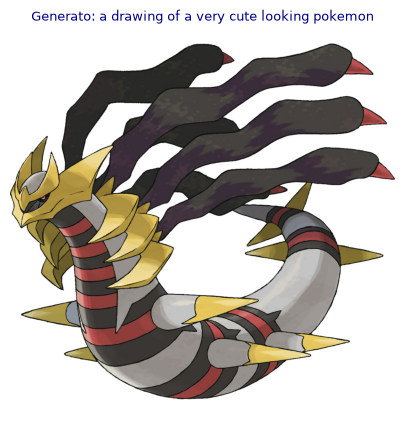

Descrizione Originale: a drawing of a very cute looking pokemon
Descrizione Generata: a drawing of a very cute looking pokemon
--------------------------------------------------


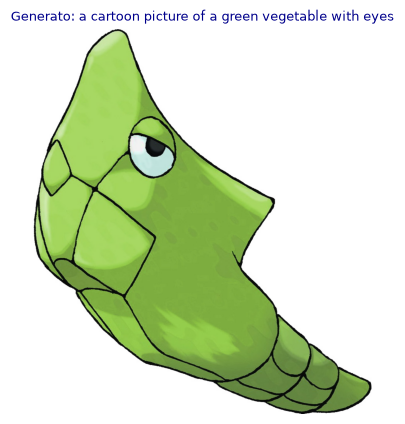

Descrizione Originale: a cartoon picture of a green vegetable with eyes
Descrizione Generata: a cartoon picture of a green vegetable with eyes
--------------------------------------------------


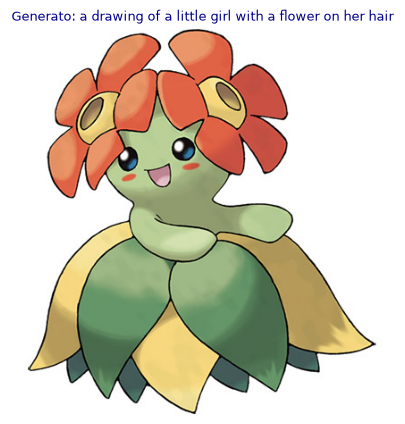

Descrizione Originale: a drawing of a little girl with a flower in her hair
Descrizione Generata: a drawing of a little girl with a flower on her hair
--------------------------------------------------


In [1]:
import os
# Configurazione del backend di Keras: impostiamo PyTorch come motore di calcolo prima di importare Keras.
# Questa operazione e' fondamentale per utilizzare la potenza di PyTorch all'interno dell'ecosistema Keras.
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from datasets import load_dataset

# -------------------------------------------------------------------------------------------------
# PARAMETRI DI CONFIGURAZIONE
# -------------------------------------------------------------------------------------------------
# Definiamo le costanti che guideranno l'architettura del modello e il processo di addestramento.
BATCH_SIZE = 64            # Numero di campioni elaborati contemporaneamente per ogni iterazione.
IMAGE_SIZE = (224, 224)    # Dimensione standard richiesta da EfficientNetB0 per le immagini in input.
VOCAB_SIZE = 5000          # Dimensione massima del vocabolario (le 5000 parole piu' frequenti).
SEQUENCE_LENGTH = 25       # Lunghezza massima delle descrizioni testuali generate.
EMBED_DIM = 256            # Dimensione dello spazio vettoriale per la rappresentazione delle parole.
LATENT_DIM = 512           # Numero di unità nei livelli densi e nell'LSTM per catturare la semantica.
EPOCHS = 15                # Numero di cicli completi di addestramento sul dataset.

print("--- 1. Caricamento Dataset Pokemon ---")

try:
    # Carichiamo un dataset pubblico contenente immagini di Pokemon e le relative descrizioni (captions).
    # Il dataset include colonne per immagini, testo in inglese ('en_text') e cinese.
    dataset = load_dataset("svjack/pokemon-blip-captions-en-zh", split="train")
    print(f"Dataset caricato: {len(dataset)} campioni trovati.")
except Exception as e:
    print(f"Errore durante il caricamento del dataset: {e}")
    dataset = []

# -------------------------------------------------------------------------------------------------
# 2. PREPARAZIONE DEI DATI (IMMAGINI E TESTO)
# -------------------------------------------------------------------------------------------------
print("\n--- 2. Preprocessing dei Dati ---")

# Gestione del Testo: Estrazione e formattazione delle descrizioni.
# Aggiungiamo i token di controllo <start> e <end> per istruire il modello sull'inizio e la fine di una frase.
captions = []
for item in dataset:
    # Puliamo il testo da eventuali ritorni a capo per mantenere la coerenza.
    clean_text = item['en_text'].replace("\n", "")
    captions.append(f"startseq {clean_text} endseq")

# Creazione del Vettorizzatore: Converte le stringhe in sequenze numeriche leggibili dal modello.
# 'standardize' converte in minuscolo e rimuove la punteggiatura automaticamente.
vectorizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH,
    standardize='lower_and_strip_punctuation'
)

# Adattiamo il vettorizzatore al nostro testo per costruire il vocabolario interno.
vectorizer.adapt(captions)
print("Vocabolario costruito correttamente.")

# Modello Visivo: Utilizziamo EfficientNetB0 pre-addestrato su ImageNet come estrattore di caratteristiche.
# 'include_top=False' rimuove la parte finale del modello (classificazione), permettendoci di ottenere i vettori visivi puri.
cnn_base = keras.applications.EfficientNetB0(
    include_top=False, 
    weights='imagenet', 
    pooling='avg'
)
# Congeliamo i pesi della CNN: non vogliamo ri-addestrare l'estrattore di immagini, ma solo il nostro decoder.
cnn_base.trainable = False

def extract_visual_features(hf_dataset):
    """
    Questa funzione attraversa l'intero dataset, processa le immagini e usa la CNN 
    per trasformare ogni immagine in un vettore di caratteristiche (1280 dimensioni).
    """
    features = []
    print("Inizio estrazione delle caratteristiche visive...")
    
    batch_img = []
    for i, item in enumerate(hf_dataset):
        # Convertiamo l'oggetto immagine in formato RGB e ridimensioniamolo alle specifiche della rete.
        img = item['image'].convert('RGB').resize(IMAGE_SIZE)
        img = keras.utils.img_to_array(img)
        batch_img.append(img)
        
        # Elaborazione a blocchi (batch) per velocizzare l'inferenza della CNN.
        if len(batch_img) == BATCH_SIZE or i == len(hf_dataset) - 1:
            batch_arr = np.array(batch_img)
            # Otteniamo le rappresentazioni numeriche dell'immagine.
            preds = cnn_base.predict(batch_arr, verbose=0)
            features.extend(preds)
            batch_img = [] # Svuotiamo il buffer per il prossimo batch.
            
            if i % 200 == 0: 
                print(f"Elaborati {i} campioni...")
                
    return np.array(features)

# Eseguiamo l'estrazione: questo passaggio trasforma le immagini in dati pronti per il training.
image_features = extract_visual_features(dataset)
print(f"Forma dei vettori visivi estratti: {image_features.shape}")

# -------------------------------------------------------------------------------------------------
# 3. CREAZIONE DELLE SEQUENZE PER L'ADDESTRAMENTO
# -------------------------------------------------------------------------------------------------
print("\n--- 3. Creazione delle Sequenze di Training ---")

X_img_train = []   # Input 1: Caratteristiche dell'immagine.
X_text_train = []  # Input 2: Parte della frase generata finora.
y_train = []       # Output: La parola successiva corretta.

# Trasformiamo tutte le caption in numeri.
encoded_captions = vectorizer(captions).cpu().numpy()

# Tecnica del Teacher Forcing:
# Per ogni immagine e descrizione, creiamo piu' campioni di addestramento.
# Es: "Un Pokemon rosso" diventa:
# 1. Immagine + "<start>" -> "Un"
# 2. Immagine + "<start> Un" -> "Pokemon"
# 3. Immagine + "<start> Un Pokemon" -> "rosso"
for i in range(len(encoded_captions)):
    cap = encoded_captions[i]
    # Identifichiamo dove finisce la frase reale (escludendo gli zeri del padding).
    try:
        end = list(cap).index(0)
    except ValueError:
        end = len(cap)
        
    for j in range(1, end):
        # Associa l'immagine corrente al contesto testuale parziale.
        X_img_train.append(image_features[i])
        
        # Prepara la sequenza di input parziale con padding.
        seq_in = cap[:j]
        seq_padded = np.pad(seq_in, (0, SEQUENCE_LENGTH - len(seq_in)), 'constant')
        X_text_train.append(seq_padded)
        
        # La parola "target" e' quella che segue immediatamente la sequenza di input.
        y_train.append(cap[j])

# Conversione finale in array NumPy per il consumo da parte di Keras.
X_img_train = np.array(X_img_train)
X_text_train = np.array(X_text_train)
y_train = np.array(y_train)

print(f"Totale campioni generati per il training: {len(y_train)}")

# -------------------------------------------------------------------------------------------------
# 4. ARCHITETTURA DEL MODELLO
# -------------------------------------------------------------------------------------------------
print("\n--- 4. Costruzione e Addestramento del Modello ---")

# Ramo Immagine (Encoder Visivo):
# Prende il vettore da 1280 di EfficientNet e lo proietta nello spazio latente comune.
input_img = keras.Input(shape=(1280,), name="input_immagine")
x = keras.layers.Dropout(0.5)(input_img) # Regolarizzazione per evitare l'overfitting.
x = keras.layers.Dense(LATENT_DIM, activation='relu')(x)

# Ramo Testo (Rete Ricorrente):
# Prende la sequenza di parole e usa un'Embedding per mapparne il significato.
input_txt = keras.Input(shape=(SEQUENCE_LENGTH,), name="input_testo")
y = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(input_txt)
y = keras.layers.Dropout(0.5)(y)
y = keras.layers.LSTM(LATENT_DIM)(y) # L'LSTM ricorda il contesto delle parole precedenti.

# Fusione e Output:
# Uniamo l'informazione visiva (cosa vede la rete) con quella testuale (cosa ha scritto finora).
decoder = keras.layers.Add()([x, y])
decoder = keras.layers.Dense(LATENT_DIM, activation='relu')(decoder)
# Il livello finale ha tanti neuroni quante sono le parole nel vocabolario.
# Softmax restituisce la probabilita' per ogni singola parola.
outputs = keras.layers.Dense(VOCAB_SIZE, activation='softmax')(decoder)

# Compilazione del modello completo.
model = keras.Model(inputs=[input_img, input_txt], outputs=outputs)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

# Fase di Addestramento:
# Il modello impara a prevedere la parola successiva basandosi sull'immagine e il testo precedente.
model.fit(
    [X_img_train, X_text_train], 
    y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------------------------------------------------------------------------
# 5. GENERAZIONE DI DESCRIZIONI (INFERENZA)
# -------------------------------------------------------------------------------------------------
print("\n--- 5. Generatore di Descrizioni Pokedex ---")

# Mappa inversa: dai numeri alle parole per leggere il risultato.
vocab = vectorizer.get_vocabulary()
index_to_word = {idx: word for idx, word in enumerate(vocab)}

def generate_description(img_idx):
    """
    Funzione che genera una frase parola per parola per una data immagine.
    Il processo e' iterativo: ogni parola generata rientra nel modello come input.
    """
    # Recuperiamo i dettagli visivi dell'immagine selezionata.
    feat = image_features[img_idx].reshape(1, -1)
    
    # Inizializziamo il processo con il token di partenza.
    start_idx = vocab.index("startseq")
    curr_seq = [start_idx]
    
    sentence = []
    
    # Generiamo una parola alla volta fino al limite massimo o al token di fine.
    for _ in range(SEQUENCE_LENGTH):
        # Prepariamo la sequenza attuale con il padding necessario.
        padded = np.pad(curr_seq, (0, SEQUENCE_LENGTH - len(curr_seq)), 'constant').reshape(1, -1)
        
        # Chiediamo al modello di prevedere la parola successiva.
        preds = model.predict([feat, padded], verbose=0)
        # Scegliamo la parola con la probabilita' piu' alta.
        next_idx = np.argmax(preds)
        word = index_to_word.get(next_idx, '?')
        
        # Se il modello emette il token di fine, la frase e' completa.
        if word == "endseq":
            break
            
        sentence.append(word)
        # Aggiorniamo la sequenza per la prossima iterazione.
        curr_seq.append(next_idx)
        
    return " ".join(sentence)

# Test finale su campioni casuali del dataset.
for _ in range(3):
    idx = random.randint(0, len(dataset)-1)
    
    generated_text = generate_description(idx)
    real_text = dataset[idx]['en_text']
    
    # Visualizzazione dell'immagine e del risultato.
    plt.figure(figsize=(5,5))
    plt.imshow(dataset[idx]['image'])
    plt.axis('off')
    plt.title(f"Generato: {generated_text}", fontsize=9, color='darkblue')
    plt.show()
    
    print(f"Descrizione Originale: {real_text}")
    print(f"Descrizione Generata: {generated_text}")
    print("-" * 50)